<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/SenPredicSTLSTMAFCPresaOk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predicciones con Red Neuronal Recorrente LSTM con AFC y Decomposicion Estacional

In [ ]:
# 0. Fijar semillas aleatorias para reproducibilidad
import os
import random
import numpy as np
import tensorflow as tf

def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Para versiones más recientes de TensorFlow, es posible que también necesites:
    # tf.keras.utils.set_random_seed(seed)

set_all_seeds()

# 1. Instalación de librerías (ya ejecutado anteriormente)
!pip install keras-tuner -q # Descomentar si es necesario

# 2. Importación de las librerías necesarias
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout # Cambiado GRU a LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import keras_tuner as kt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 3. Carga y preparación de los datos
try:
    df = pd.read_excel('datos_fusionados_operantes.xlsx')
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'datos_fusionados_operantes.xlsx' se haya cargado en tu entorno de Colab.")
    df = pd.DataFrame()

if not df.empty:
    # Seleccionamos el sensor para el ejemplo
    sensor_tag = 'EM-E-001/1 | (2736) - (DEFORMACION)'
    df_sensor = df[df['nombre_etiqueta'] == sensor_tag].copy()

    # Comprobar si df_sensor está vacío
    if df_sensor.empty:
        print(f"Error: No se encontraron datos para la etiqueta de sensor '{sensor_tag}'. Por favor, verifica la etiqueta del sensor y los datos.")
    else:
        df_sensor['fecha'] = pd.to_datetime(df_sensor['fecha'])
        df_sensor = df_sensor.sort_values('fecha').set_index('fecha')

        # 4. Escalado de datos
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(df_sensor[['valor_promedio']])

        # Comprobar si hay valores NaN o infinitos en los datos escalados
        if np.isnan(scaled_data).any() or np.isinf(scaled_data).any():
            print("Error: Los datos escalados contienen valores NaN o infinitos. Por favor, verifica tus datos y el proceso de escalado.")
        else:
             print("Datos cargados, preparados y escalados exitosamente.")
else:
    print("El DataFrame df está vacío. No se pudo cargar el archivo.")

Datos cargados, preparados y escalados exitosamente.


<Figure size 1200x600 with 0 Axes>

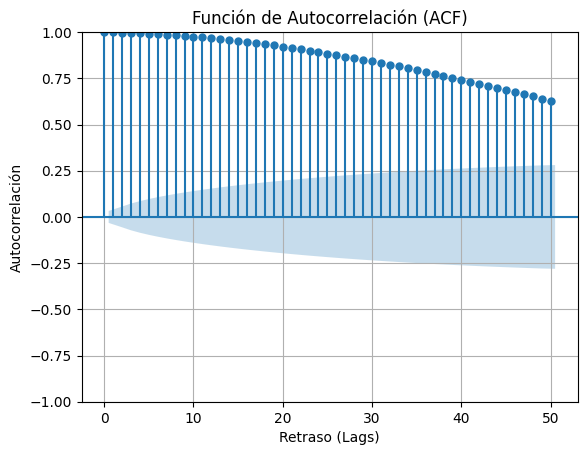


--- Análisis de ACF ---
Observa el gráfico de ACF para identificar el punto donde la autocorrelación decae significativamente.
Este punto puede sugerir un tamaño de ventana deslizante (sequence_length) apropiado para el modelo LSTM.


In [ ]:
# Análisis de la Función de Autocorrelación (ACF) para estimar la ventana deslizante
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Seleccionamos la serie de tiempo a analizar (la columna 'valor_promedio' del sensor seleccionado)
# Asegúrate de que df_sensor esté disponible y no esté vacío antes de ejecutar esto
if not df_sensor.empty:
    time_series_data = df_sensor['valor_promedio'].dropna() # Eliminar NaNs si los hay

    # Trazar la función de autocorrelación
    plt.figure(figsize=(12, 6))
    plot_acf(time_series_data, lags=50) # Puedes ajustar 'lags' según la longitud de tu serie
    plt.title('Función de Autocorrelación (ACF)')
    plt.xlabel('Retraso (Lags)')
    plt.ylabel('Autocorrelación')
    plt.grid(True)
    plt.show()

    print("\n--- Análisis de ACF ---")
    print("Observa el gráfico de ACF para identificar el punto donde la autocorrelación decae significativamente.")
    print("Este punto puede sugerir un tamaño de ventana deslizante (sequence_length) apropiado para el modelo LSTM.") # Cambiado GRU a LSTM
else:
    print("El DataFrame df_sensor está vacío. No se puede realizar el análisis de ACF.")

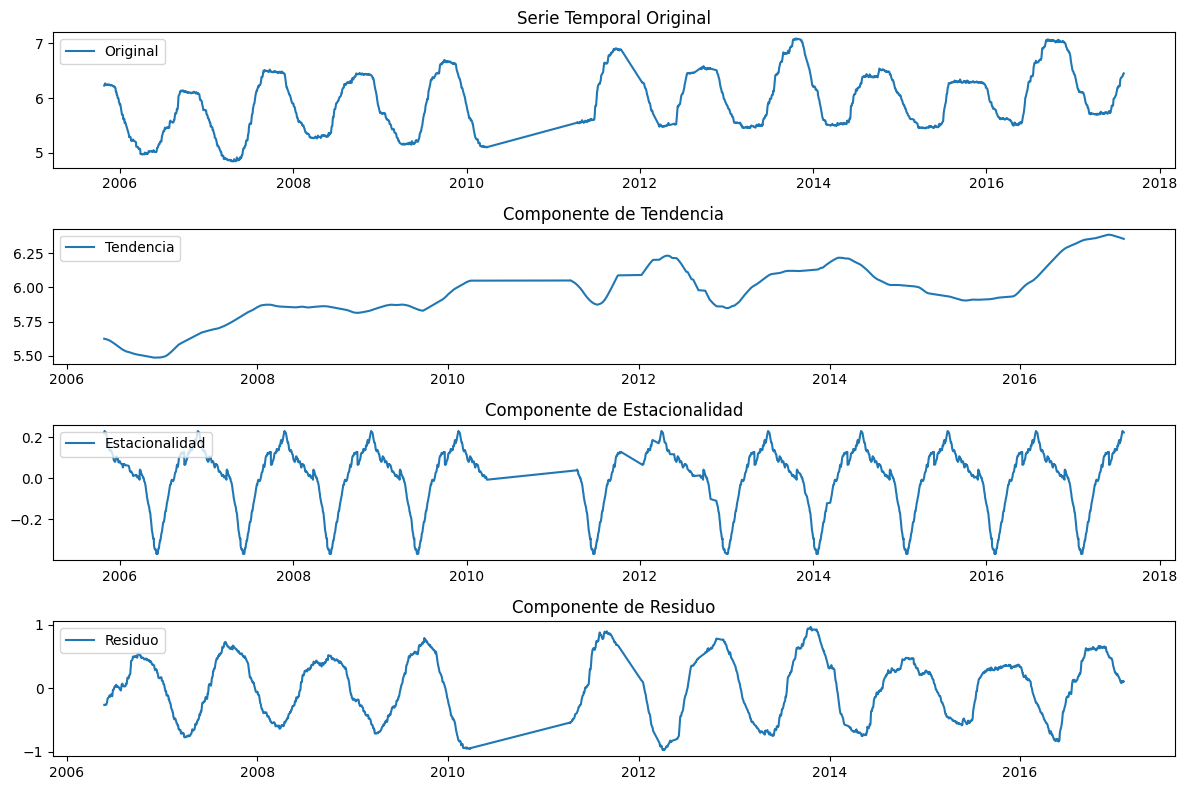


--- Análisis de Descomposición Estacional ---
Observa los gráficos para identificar la tendencia a largo plazo, los patrones estacionales repetitivos y las variaciones aleatorias (residuos).


In [ ]:
# Descomposición Estacional de la Serie Temporal
from statsmodels.tsa.seasonal import seasonal_decompose

# Asegúrate de que time_series_data esté disponible del análisis de ACF
if 'time_series_data' in locals() and time_series_data is not None and not time_series_data.empty:
    # Realizar la descomposición aditiva. Si la magnitud de la estacionalidad
    # es independiente del nivel de la serie, usa 'additive'.
    # Si la magnitud de la estacionalidad cambia proporcionalmente con el nivel, usa 'multiplicative'.
    # Basado en la visualización inicial y el conocimiento de los datos, elegimos aditiva por ahora.
    decomposition = seasonal_decompose(time_series_data, model='additive', period=365) # Ajusta el período según la frecuencia de tus datos (ej. 365 para datos diarios con estacionalidad anual)

    # Trazar la descomposición
    plt.figure(figsize=(12, 8))
    plt.subplot(411)
    plt.plot(time_series_data, label='Original')
    plt.legend(loc='upper left')
    plt.title('Serie Temporal Original')

    plt.subplot(412)
    plt.plot(decomposition.trend, label='Tendencia')
    plt.legend(loc='upper left')
    plt.title('Componente de Tendencia')

    plt.subplot(413)
    plt.plot(decomposition.seasonal, label='Estacionalidad')
    plt.legend(loc='upper left')
    plt.title('Componente de Estacionalidad')

    plt.subplot(414)
    plt.plot(decomposition.resid, label='Residuo')
    plt.legend(loc='upper left')
    plt.title('Componente de Residuo')

    plt.tight_layout()
    plt.show()

    print("\n--- Análisis de Descomposición Estacional ---")
    print("Observa los gráficos para identificar la tendencia a largo plazo, los patrones estacionales repetitivos y las variaciones aleatorias (residuos).")

else:
    print("Error: 'time_series_data' no está disponible o está vacío. Asegúrate de que los pasos de carga y preparación de datos, y el análisis de ACF se hayan ejecutado correctamente.")

In [ ]:
# Definir el valor de sequence_length basado en el análisis de ACF y la Decomposición Estacional
# Asumiendo que el análisis de ACF previo sugiere un valor, lo definimos aquí.
sequence_length = 365 # Puedes ajustar este valor según tu análisis de ACF

# 5. Función para crear secuencias
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length, 0]) # Añadir el valor de la única característica
    return np.array(X), np.array(y)

# Asegúrate de que scaled_data esté disponible de los pasos anteriores
if 'scaled_data' in locals() and scaled_data is not None:
    X, y = create_sequences(scaled_data, sequence_length)

    # Comprobar si hay valores NaN o infinitos en las secuencias generadas (X e y)
    if np.isnan(X).any() or np.isinf(X).any():
         print("Error: Las secuencias generadas (X) contienen valores NaN o infinitos. Por favor, verifica tus datos.")
    elif np.isnan(y).any() or np.isinf(y).any():
         print("Error: Las secuencias generadas (y) contienen valores NaN o infinitos. Por favor, verifica tus datos.")
    else:
        # Reshape de X para que sea compatible con la capa LSTM [muestras, timesteps, features]
        X = np.reshape(X, (X.shape[0], X.shape[1], 1))

        # 6. División de datos (cronológica)
        split_point = int(len(X) * 0.8)
        X_train, X_test = X[:split_point], X[split_point:]
        y_train, y_test = y[:split_point], y[split_point:]

        # Comprobar si hay valores NaN o infinitos en los conjuntos de entrenamiento/prueba
        if np.isnan(X_train).any() or np.isinf(X_train).any() or \
           np.isnan(X_test).any() or np.isinf(X_test).any() or \
           np.isnan(y_train).any() or np.isinf(y_train).any() or \
           np.isnan(y_test).any() or np.isinf(y_test).any():
            print("Error: Los conjuntos de entrenamiento o prueba contienen valores NaN o infinitos. Por favor, verifica tus datos.")
        else:
            # 7. Construcción del modelo para KerasTuner (Actualizado para usar LSTM)
            def build_model(hp):
                model = Sequential()
                model.add(LSTM( # Cambiado GRU a LSTM
                    units=hp.Int('units_lstm', min_value=16, max_value=64, step=16), # Cambiado nombre del hiperparámetro
                    return_sequences=False,
                    input_shape=(X_train.shape[1], X_train.shape[2])
                ))
                model.add(Dropout(rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
                model.add(Dense(1)) # Capa de salida

                model.compile(
                    optimizer=keras.optimizers.Adam(
                        hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5]),
                        clipnorm=1.0
                    ),
                    loss='mean_squared_error'
                )
                return model

            # 8. Configuración del autoajuste (Tuner)
            # Reiniciar el Tuner si se ejecuta en el mismo entorno
            # Eliminar caracteres no válidos para nombres de archivo del sensor_tag para el nombre del proyecto
            safe_sensor_tag = sensor_tag.replace('/', '_').replace('|', '_').replace(' ', '_').replace(':', '_')
            project_name = f'lstm_sensor_tuning_{safe_sensor_tag}' # Incluido sensor_tag en el nombre del proyecto

            tuner = kt.Hyperband(
                build_model,
                objective='val_loss',
                max_epochs=50,
                factor=3,
                directory='keras_tuner_dir',
                project_name=project_name # Usar el nombre del proyecto con sensor_tag
            )

            print(f"--- Iniciando búsqueda de hiperparámetros con LSTM para el sensor: {sensor_tag} ---") # Actualizado mensaje
            stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
            tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[stop_early], verbose=2)

            # 9. Obtener el mejor modelo y entrenarlo
            best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
            print(f"\n--- Mejores hiperparámetros encontrados (LSTM) para el sensor: {sensor_tag} ---") # Actualizado mensaje
            print(f"Unidades LSTM: {best_hps.get('units_lstm')}") # Cambiado nombre del hiperparámetro
            print(f"Dropout: {best_hps.get('dropout')}")
            print(f"Tasa de aprendizaje: {best_hps.get('learning_rate')}")

            # Obtener el mejor modelo directamente del afinador
            model = tuner.get_best_models(num_models=1)[0]

            history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[stop_early], verbose=0)
            print("\n--- Modelo LSTM final entrenado ---")
else:
    print("Error: scaled_data no está disponible. Asegúrate de que los pasos de carga y escalado de datos se hayan ejecutado correctamente.")

Trial 80 Complete [00h 01m 19s]
val_loss: 0.0006957841105759144

Best val_loss So Far: 7.884157821536064e-05
Total elapsed time: 01h 19m 40s

--- Mejores hiperparámetros encontrados (LSTM) para el sensor: EM-E-001/1 | (2736) - (DEFORMACION) ---
Unidades LSTM: 32
Dropout: 0.1
Tasa de aprendizaje: 0.001

--- Modelo LSTM final entrenado ---


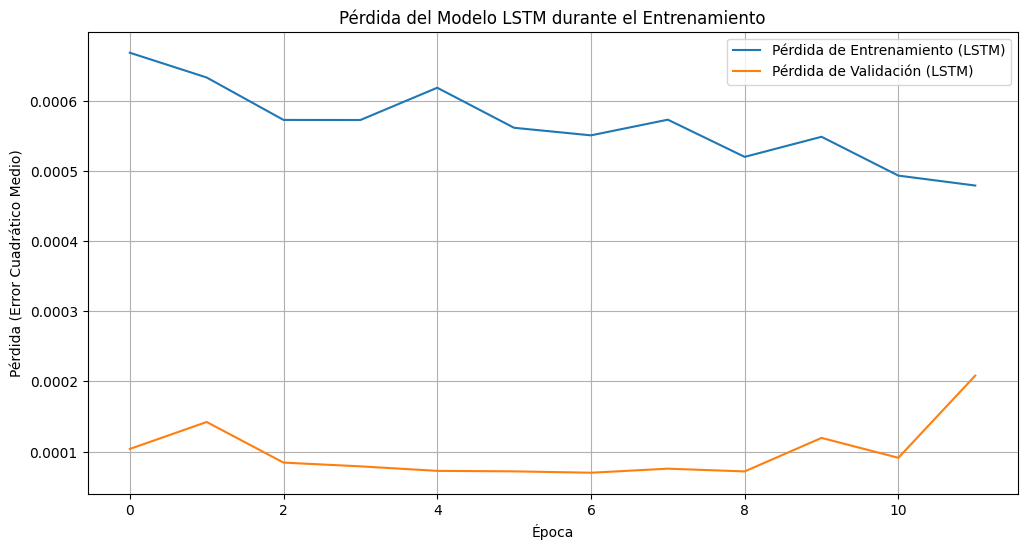

In [ ]:
# 10. Visualizar la evolución de la función de pérdida para el modelo LSTM
# Asegúrate de que 'history' esté disponible del entrenamiento del modelo
if 'history' in locals() and history is not None:
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (LSTM)') # Cambiado etiqueta
    plt.plot(history.history['val_loss'], label='Pérdida de Validación (LSTM)') # Cambiado etiqueta
    plt.title('Pérdida del Modelo LSTM durante el Entrenamiento') # Cambiado título
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Error Cuadrático Medio)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Error: 'history' no está disponible. Asegúrate de que el modelo LSTM se haya entrenado correctamente.")

In [ ]:
# 11. Realizar y des-escalar las predicciones y calcular métricas de evaluación para el modelo LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import pandas as pd # Import pandas for date handling

# Asegúrate de que model, X_test, y_test y scaler estén disponibles
if 'model' in locals() and model is not None and \
   'X_test' in locals() and X_test is not None and \
   'y_test' in locals() and y_test is not None and \
   'scaler' in locals() and scaler is not None:

    predictions_scaled = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions_scaled)
    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)) # Reshape y_test aquí

    # Calcular métricas de evaluación para el modelo LSTM
    mse = mean_squared_error(y_test_real, predictions)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_test_real, predictions)
    r2 = r2_score(y_test_real, predictions)

    print(f"Evaluación del Modelo LSTM para el Sensor: {sensor_tag}") # Cambiado título
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
else:
    print("Error: Las variables necesarias (model, X_test, y_test, scaler) no están disponibles. Asegúrate de que los pasos anteriores se hayan ejecutado correctamente.")

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Evaluación del Modelo LSTM para el Sensor: EM-E-001/1 | (2736) - (DEFORMACION)
MSE: 0.0014
RMSE: 0.0370
MAE: 0.0312
R2: 0.9944


In [ ]:
# 12. Realizar predicciones futuras iterativamente con el modelo LSTM

num_future_steps = 30  # Definir el número de pasos futuros a predecir (por ejemplo, 30 períodos)
future_predictions_scaled = []

# Asegúrate de que scaled_data, sequence_length y model estén disponibles
if 'scaled_data' in locals() and scaled_data is not None and \
   'sequence_length' in locals() and sequence_length is not None and \
   'model' in locals() and model is not None:

    # Comenzar con la última secuencia de los datos históricos escalados
    current_sequence = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)

    for _ in range(num_future_steps):
        # Predecir el siguiente paso
        next_prediction_scaled = model.predict(current_sequence)

        # Añadir la predicción a la lista
        future_predictions_scaled.append(next_prediction_scaled[0][0])

        # Actualizar la secuencia de entrada: eliminar el primer elemento y añadir la nueva predicción
        current_sequence = np.append(current_sequence[:, 1:, :], next_prediction_scaled.reshape(1, 1, 1), axis=1)

    # Des-escalar las predicciones futuras escaladas
    future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

    print(f"\n--- Predicciones para los próximos {num_future_steps} períodos con Modelo LSTM ---") # Cambiado título
    for i, pred in enumerate(future_predictions):
        print(f"Período {i+1}: {pred[0]:.4f}")
else:
    print("Error: Las variables necesarias (scaled_data, sequence_length, model) no están disponibles. Asegúrate de que los pasos anteriores se hayan ejecutado correctamente.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

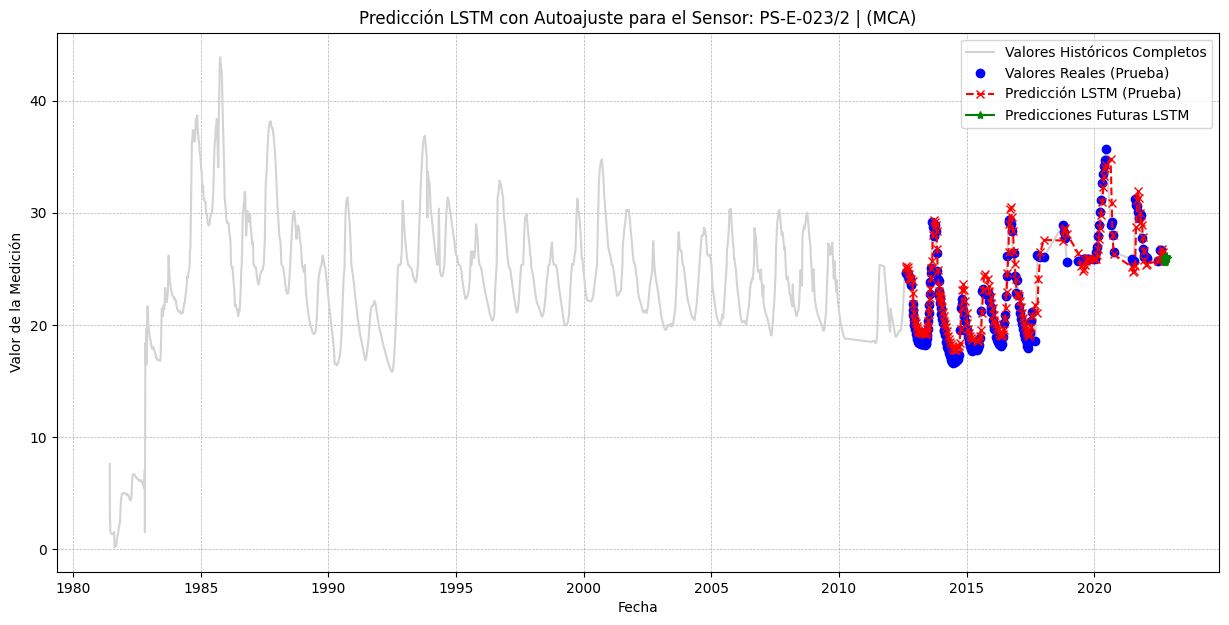

In [ ]:
# 13. Visualización de predicciones históricas y futuras del modelo LSTM

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd # Import pandas for date handling

# Asegúrate de que df_sensor, split_point, sequence_length, y_test_real, predictions, future_predictions y num_future_steps estén disponibles
if 'df_sensor' in locals() and df_sensor is not None and \
   'split_point' in locals() and split_point is not None and \
   'sequence_length' in locals() and sequence_length is not None and \
   'y_test_real' in locals() and y_test_real is not None and \
   'predictions' in locals() and predictions is not None and \
   'future_predictions' in locals() and future_predictions is not None and \
   'num_future_steps' in locals() and num_future_steps is not None:

    # Determinar las fechas para las predicciones futuras
    # El conjunto de prueba comienza en el índice split_point de las secuencias (X, y)
    # Necesitamos encontrar la fecha correspondiente en el índice original de df_sensor

    # Calcular el índice en el df_sensor original que corresponde al inicio de las secuencias del conjunto de prueba
    start_index_test_data = split_point + sequence_length

    # Obtener las fechas para el conjunto de prueba del índice original de df_sensor
    test_dates = df_sensor.index[start_index_test_data:]

    # Determinar la fecha para el inicio de las predicciones futuras
    last_historical_date = df_sensor.index[-1]
    # Ensure the frequency is correctly inferred or set for accurate future dates
    if df_sensor.index.freq is None:
        # Attempt to infer frequency if not set
        inferred_freq = pd.infer_freq(df_sensor.index)
        if inferred_freq:
            future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(inferred_freq), periods=num_future_steps, freq=inferred_freq)
        else:
            # Default to daily if frequency cannot be inferred
            future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=num_future_steps, freq='D')
            print("Warning: Could not infer frequency from df_sensor index. Using daily frequency for future dates.")
    else:
        future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(df_sensor.index.freq), periods=num_future_steps, freq=df_sensor.index.freq)


    plt.figure(figsize=(15, 7))
    plt.plot(df_sensor.index, df_sensor['valor_promedio'], label='Valores Históricos Completos', color='lightgray')
    plt.plot(test_dates, y_test_real, label='Valores Reales (Prueba)', color='blue', marker='o', linestyle='None')
    plt.plot(test_dates, predictions, label='Predicción LSTM (Prueba)', color='red', marker='x', linestyle='--') # Añadir predicciones futuras
    plt.plot(future_dates, future_predictions, label='Predicciones Futuras LSTM', color='green', marker='*', linestyle='-') # Añadir predicciones futuras

    plt.title(f'Predicción LSTM con Autoajuste para el Sensor: {sensor_tag}') # Cambiado el título
    plt.xlabel('Fecha')
    plt.ylabel('Valor de la Medición')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()
else:
    print("Error: Las variables necesarias para la visualización no están disponibles. Asegúrate de que los pasos anteriores se hayan ejecutado correctamente.")

In [ ]:
# 14. Guardar el modelo LSTM entrenado
# Asegúrate de que model y sensor_tag estén disponibles
if 'model' in locals() and model is not None and 'sensor_tag' in locals() and sensor_tag is not None:
    # Eliminar caracteres no válidos para nombres de archivo del sensor_tag
    safe_sensor_tag = sensor_tag.replace('/', '_').replace('|', '_').replace(' ', '_').replace(':', '_')
    model_save_path = f'lstm_sensor_model_{safe_sensor_tag}.h5' # Incluido sensor_tag en el nombre del archivo
    model.save(model_save_path)

    print(f"\n--- Modelo LSTM guardado exitosamente ---")
    print(f"Ruta del archivo: {model_save_path}")
else:
    print("Error: El modelo o el sensor_tag no están disponibles para guardar. Asegúrate de que el entrenamiento se haya completado correctamente y que 'sensor_tag' esté definido.")


--- Modelo LSTM guardado exitosamente ---
Ruta del archivo: lstm_sensor_model_PS-E-023_2___(MCA).h5


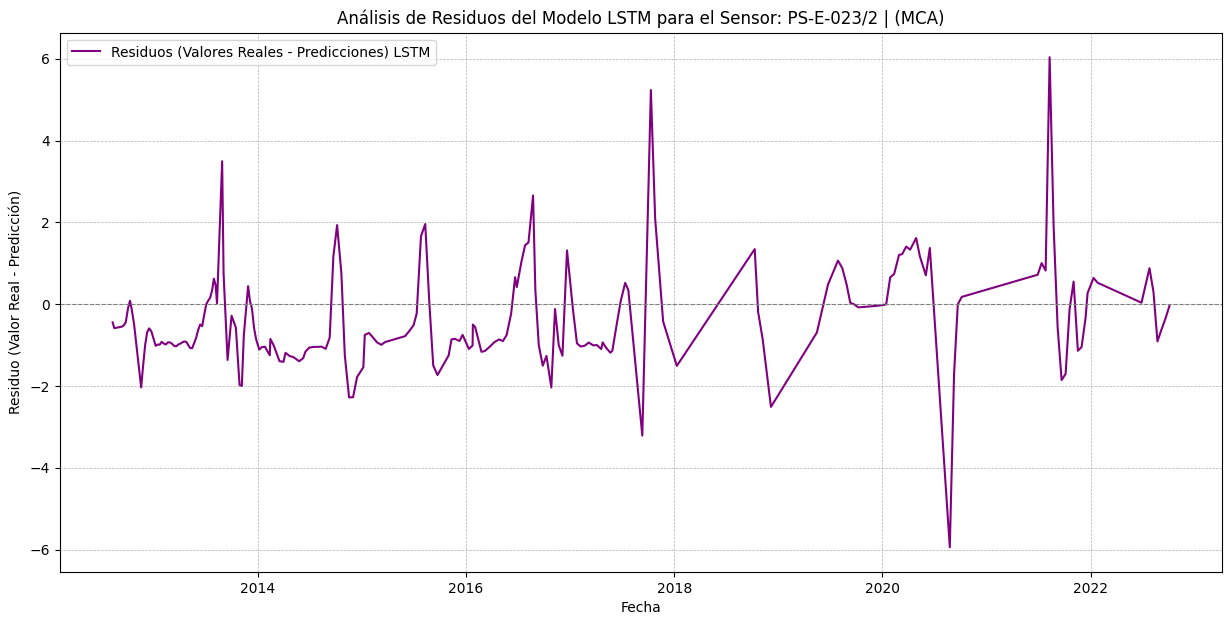

In [ ]:
# Calcular residuos para el modelo LSTM
# Asegúrate de que y_test_real y predictions estén disponibles
if 'y_test_real' in locals() and y_test_real is not None and \
   'predictions' in locals() and predictions is not None:

    residuals = y_test_real - predictions

    # 15. Visualización de residuos para el modelo LSTM
    plt.figure(figsize=(15, 7))
    plt.plot(test_dates, residuals, label='Residuos (Valores Reales - Predicciones) LSTM', color='purple') # Cambiado etiqueta
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Añadir una línea horizontal en cero

    plt.title(f'Análisis de Residuos del Modelo LSTM para el Sensor: {sensor_tag}') # Cambiado el título para reflejar LSTM
    plt.xlabel('Fecha')
    plt.ylabel('Residuo (Valor Real - Predicción)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()
else:
    print("Error: Las variables necesarias para calcular y visualizar residuos no están disponibles. Asegúrate de que los pasos de predicción se hayan ejecutado correctamente.")

In [ ]:
# 16. Identificar fechas con los residuos positivos y negativos más grandes (Top 10) para el modelo LSTM

# Asegúrate de que residuals y test_dates estén disponibles
if 'residuals' in locals() and residuals is not None and \
   'test_dates' in locals() and test_dates is not None:

    # Obtener los índices de los residuos positivos más grandes (orden descendente)
    top_10_positive_indices = np.argsort(residuals.flatten())[::-1][:10]

    # Obtener los índices de los residuos negativos más grandes (orden ascendente)
    top_10_negative_indices = np.argsort(residuals.flatten())[:10]

    print(f"\n--- Fechas con los 10 Residuos Positivos Más Grandes (LSTM) ---") # Cambiado título
    for i in top_10_positive_indices:
        date_positive = test_dates[i]
        value_positive = residuals[i][0]
        print(f"Fecha: {date_positive.strftime('%Y-%m-%d')} (Residuo: {value_positive:.4f})")

    print(f"\n--- Fechas con los 10 Residuos Negativos Más Grandes (LSTM) ---") # Cambiado título
    for i in top_10_negative_indices:
        date_negative = test_dates[i]
        value_negative = residuals[i][0]
        print(f"Fecha: {date_negative.strftime('%Y-%m-%d')} (Residuo: {value_negative:.4f})")
else:
    print("Error: Las variables necesarias para identificar los residuos más grandes no están disponibles. Asegúrate de que los residuos se hayan calculado correctamente.")


--- Fechas con los 10 Residuos Positivos Más Grandes (LSTM) ---
Fecha: 2021-08-09 (Residuo: 6.0390)
Fecha: 2017-10-11 (Residuo: 5.2363)
Fecha: 2013-08-30 (Residuo: 3.4960)
Fecha: 2016-08-24 (Residuo: 2.6591)
Fecha: 2017-10-26 (Residuo: 2.0984)
Fecha: 2015-08-12 (Residuo: 1.9601)
Fecha: 2014-10-07 (Residuo: 1.9342)
Fecha: 2021-08-23 (Residuo: 1.8982)
Fecha: 2015-07-28 (Residuo: 1.6590)
Fecha: 2020-04-28 (Residuo: 1.6171)

--- Fechas con los 10 Residuos Negativos Más Grandes (LSTM) ---
Fecha: 2020-08-24 (Residuo: -5.9434)
Fecha: 2017-09-11 (Residuo: -3.2148)
Fecha: 2018-12-06 (Residuo: -2.5115)
Fecha: 2014-11-18 (Residuo: -2.2805)
Fecha: 2014-12-02 (Residuo: -2.2752)
Fecha: 2016-10-27 (Residuo: -2.0375)
Fecha: 2012-11-19 (Residuo: -2.0350)
Fecha: 2013-11-07 (Residuo: -1.9973)
Fecha: 2013-10-30 (Residuo: -1.9752)
Fecha: 2021-09-20 (Residuo: -1.8551)


In [ ]:
# 17. Identificar y guardar todos los residuos en un archivo Excel, incluyendo el nombre del sensor en el nombre del archivo

# Asegúrate de que residuals, test_dates y sensor_tag estén disponibles
if 'residuals' in locals() and residuals is not None and \
   'test_dates' in locals() and test_dates is not None and \
   'sensor_tag' in locals() and sensor_tag is not None:

    # Crear un DataFrame con todas las fechas y residuos
    residuals_df = pd.DataFrame({
        'Fecha': test_dates,
        'Residuo': residuals.flatten() # Aplanar el array de residuos para que sea una serie
    })

    # Eliminar caracteres no válidos para nombres de archivo del sensor_tag
    safe_sensor_tag = sensor_tag.replace('/', '_').replace('|', '_').replace(' ', '_').replace(':', '_')

    # Especificar la ruta y el nombre del archivo Excel incluyendo el nombre del sensor
    excel_file_path = f'residuos_LSTM_{safe_sensor_tag}.xlsx'

    # Guardar el DataFrame en un archivo Excel
    try:
        residuals_df.to_excel(excel_file_path, index=False)
        print(f"\n--- Todos los Residuos (LSTM) guardados exitosamente ---") # Cambiado título
        print(f"Ruta del archivo: {excel_file_path}")
    except Exception as e:
        print(f"Error al guardar el archivo Excel: {e}")
else:
     print("Error: Las variables necesarias para guardar los residuos no están disponibles. Asegúrate de que los residuos se hayan calculado correctamente y que 'sensor_tag' esté definido.")


--- Todos los Residuos (LSTM) guardados exitosamente ---
Ruta del archivo: residuos_LSTM_PS-E-023_2___(MCA).xlsx
